<a href="https://colab.research.google.com/github/kady05naik/LeetCode/blob/main/2026_08_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import SparkSession
spark=SparkSession.builder.master('local').appName('myapp').getOrCreate()

**1.Write a solution to find the second highest distinct salary from the Employee table.**

If there is no second highest salary, return null
```
Example 1:
Employee table:
+----+--------+
| id | salary |
+----+--------+
| 1  | 100    |
| 2  | 200    |
| 3  | 300    |
+----+--------+
Output:
+---------------------+
| SecondHighestSalary |
+---------------------+
| 200                 |
+---------------------+
```



```
SELECT max(salary) AS SecondHighestSalary
FROM employee
WHERE salary < (SELECT MAX(salary) FROM employee);
```



In [2]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

data = [(1, 100), (2, 200), (3, 300)]
schema=("id Integer,salary Integer")
raw=spark.createDataFrame(data,schema)

WindowSpec=Window.orderBy(F.col('salary').desc())
df=raw.withColumn('rnk', F.dense_rank().over(WindowSpec))
df.select(F.col("salary").alias('SecondHighestSalary')).filter("rnk=2").show()

+-------------------+
|SecondHighestSalary|
+-------------------+
|                200|
+-------------------+





---



**2. Write a solution to find the nth highest distinct salary from the Employee table. If there are less than n distinct salaries, return null.**

The result format is in the following example.
```
Input:
Employee table:
+----+--------+
| id | salary |
+----+--------+
| 1  | 100    |
| 2  | 200    |
| 3  | 300    |
+----+--------+
n = 2
Output:
+------------------------+
| getNthHighestSalary(2) |
+------------------------+
| 200                    |
+------------------------+
```



```
CREATE FUNCTION getNthHighestSalary(N INT) RETURNS INT
BEGIN
  RETURN (
    SELECT Distinct salary
    FROM (
        SELECT
            id,
            salary,
            DENSE_RANK() OVER(ORDER BY salary DESC) AS rnk
        FROM
            employee
    )t
    WHERE rnk=n
 );
```



In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = SparkSession.builder.appName("EmployeeDataFrame").getOrCreate()

schema = StructType([
    StructField("Id", IntegerType(), True),
    StructField("Salary", IntegerType(), True)
])
data = [
    (1, 100),
    (2, 200),
    (3, 300)
]
employee_df = spark.createDataFrame(data, schema=schema)

windowSpec=Window.orderBy(F.col('salary').desc())
high_sal_df=employee_df.withColumn('rnk', F.dense_rank().over(windowSpec))
high_sal_df.select(F.col("salary").alias('highest_salary')).filter(F.col('rnk')==4).show()

+--------------+
|highest_salary|
+--------------+
+--------------+




---



**3. Write a solution to find the rank of the scores. The ranking should be
calculated according to the following rules:**

1. The scores should be ranked from the highest to the lowest.

2. If there is a tie between two scores, both should have the same ranking.

3. After a tie, the next ranking number should be the next consecutive integer value.

4. In other words, there should be no holes between ranks.

5. Return the result table ordered by score in descending order.

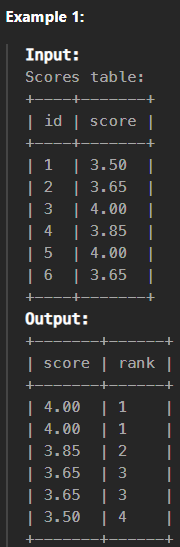



```
WITH cte_score AS
(
    SELECT
        score,
        DENSE_RANK() OVER(ORDER BY score desc) AS rnk   
    FROM scores
)
SELECT
    score,
    rnk AS 'rank'
FROM cte_score
ORDER BY rnk;
```



In [4]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

data = [
    (1, 3.5),
    (2, 3.65),
    (3, 4.0),
    (4,3.85),
    (5, 4.0),
    (6, 3.65)
]

scores_df = spark.createDataFrame(data, ['id', 'score'])

window_spec=Window.orderBy(F.col('score').desc())

score_rank_df=scores_df.withColumn('rank',F.dense_rank().over(window_spec))

score_rank_df.select(F.col('score'),
                     F.col('rank')).show()


+-----+----+
|score|rank|
+-----+----+
|  4.0|   1|
|  4.0|   1|
| 3.85|   2|
| 3.65|   3|
| 3.65|   3|
|  3.5|   4|
+-----+----+





---




**4. Write a solution to report the first name, last name, city, and state of each person in the Person table. If the address of a personId is not present in the Address table, report null instead.**

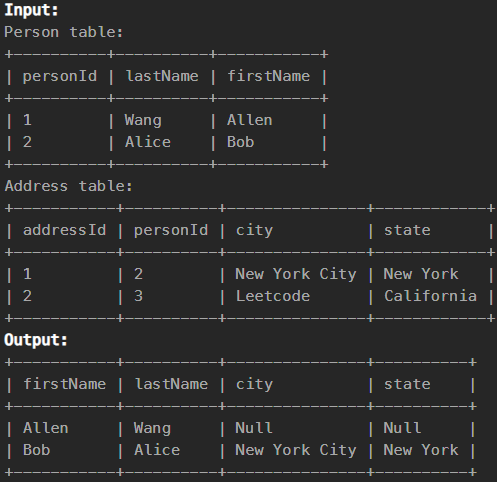

```
SELECT
    firstName,
    lastName ,
    city,
    state
FROM  person p
LEFT JOIN address a
    ON p.personId =a.personId ;
```



In [5]:
from pyspark.sql import functions as F

person_data = [
    (1, 'Allen', 'Wang'),
    (2, 'Bob', 'Alice')
]
person_df = spark.createDataFrame(person_data, ['personId', 'firstName', 'lastName'])

address_data = [
    (1, 2, 'New York City', 'New York'),
    (2, 3, 'Leetcode', 'California')
]

address_df = spark.createDataFrame(address_data, ['addressId', 'personId', 'city', 'state'])

person_address_df=person_df.join(address_df,"personId",'left')

(
    person_address_df.select("personId",
                             "firstName",
                             "lastName",
                             "city",
                             "state").show()
)


# Second way to solve this is you can simply drop column too

person_df.join(address_df,"personId",'left').drop('addressId').show()

+--------+---------+--------+-------------+--------+
|personId|firstName|lastName|         city|   state|
+--------+---------+--------+-------------+--------+
|       1|    Allen|    Wang|         NULL|    NULL|
|       2|      Bob|   Alice|New York City|New York|
+--------+---------+--------+-------------+--------+

+--------+---------+--------+-------------+--------+
|personId|firstName|lastName|         city|   state|
+--------+---------+--------+-------------+--------+
|       1|    Allen|    Wang|         NULL|    NULL|
|       2|      Bob|   Alice|New York City|New York|
+--------+---------+--------+-------------+--------+





---



**5. Find all numbers that appear at least three times consecutively.**
```
WITH cte_con_num AS(
SELECT
    num,
    LAG(num) OVER (ORDER BY id) AS pre,
    LEAD(num) OVER (ORDER BY id) AS ne
FROM logs

)

SELECT DISTINCT(num) ConsecutiveNums
FROM cte_con_num
WHERE num=pre and num=ne;
```

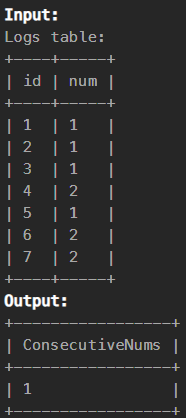


In [6]:
from pyspark.sql.window import Window
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType

logs_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("num", IntegerType(), True)
])

logs_data = [
    (1, 1),
    (2, 1),
    (3, 1),
    (4, 2),
    (5, 1),
    (6, 2),
    (7, 2)
]

logs_df = spark.createDataFrame(logs_data, schema=logs_schema)

windowSpec1=Window.orderBy(F.col('id'))

trans_df=logs_df.withColumns({
                                'prev': F.lag(F.col('num')).over(windowSpec1),
                                'next': F.lead(F.col('num')).over(windowSpec1)
                            })
(
    trans_df.filter((F.col('num')==F.col('prev')) & (F.col('num')==F.col('next')))
        .select(F.col('num').alias('ConsecutiveNums'))
        .distinct() # Corrected: Call distinct() as a DataFrame method
        .show()

)

+---------------+
|ConsecutiveNums|
+---------------+
|              1|
+---------------+





---



**6. Write a solution to find the employees who earn more than their managers.
Return the result table in any order**

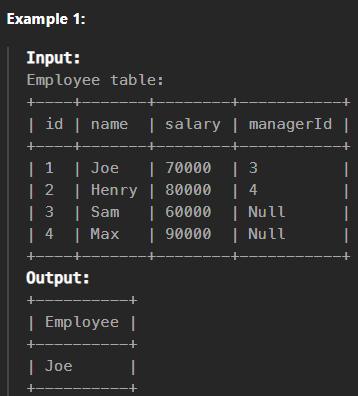
```
SELECT
    e.name AS Employee
FROM employee e
INNER JOIN employee m
    ON e.managerId =m.id
WHERE e.salary>m.salary;
```




In [7]:
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, StringType
schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("name", StringType(), True),
    StructField("salary", IntegerType(), True),
    StructField("managerId", IntegerType(), True)
])

data = [
    (1, 'Joe', 70000, 3),
    (2, 'Henry', 80000, 4),
    (3, 'Sam', 60000, None),
    (4, 'Max', 90000, None)
]


emp_df = spark.createDataFrame(data, schema=schema)

manager_df=emp_df.alias('manager_df')

emp_manager_df=emp_df.alias('e').join(emp_df.alias('m'), F.col("e.managerId")==F.col("m.id"), "inner")

emp_manager_df.select('e.name').filter(F.col("m.salary") < F.col("e.salary")).show()

+----+
|name|
+----+
| Joe|
+----+





---



**7. Write a solution to report all the duplicate emails. Note that it's guaranteed that the email field is not NULL.**

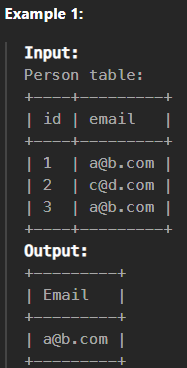

```
SELECT  email
FROM person
GROUP BY email
HAVING COUNT(email)>1;
```





In [8]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType
from pyspark.sql import functions as F

# Define schema for the Person table
person_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("email", StringType(), True)
])

# Prepare data
person_data = [
    (1, 'a@b.com'),
    (2, 'c@d.com'),
    (3, 'a@b.com')
]

# Create DataFrame
person_df = spark.createDataFrame(person_data, schema=person_schema)

(
    person_df.groupBy(F.col('email'))
              .agg(F.count('email').alias('email_cnt'))
              .filter(F.col('email_cnt')>1)
              .select(F.col('email'))
              .show()
)

+-------+
|  email|
+-------+
|a@b.com|
+-------+





---



**8. Write a solution to find all customers who never order anything.**

```
SELECT
    name AS Customers
FROM customers
WHERE id NOT IN(SELECT DISTINCT customerid FROM orders);
```
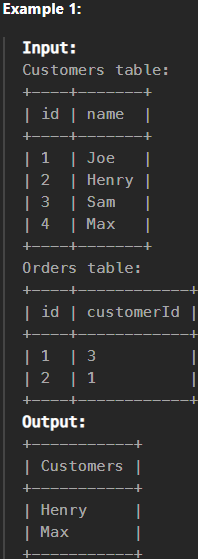


In [9]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType
from pyspark.sql import functions as F

# 1. Create Customers DataFrame
customers_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("name", StringType(), True)
])

customers_data = [
    (1, 'Joe'),
    (2, 'Henry'),
    (3, 'Sam'),
    (4, 'Max')
]

customers_df = spark.createDataFrame(customers_data, schema=customers_schema)

# 2. Create Orders DataFrame
orders_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("customerId", IntegerType(), True)
])

orders_data = [
    (1, 3),
    (2, 1)
]

orders_df = spark.createDataFrame(orders_data, schema=orders_schema)

customers_df.join(orders_df, customers_df.id==orders_df.customerId, "leftanti").select("name").show()


+-----+
| name|
+-----+
|  Max|
|Henry|
+-----+





---



**9. Write a solution to find employees who have the highest salary in each of the departments.**

```
WITH cte_high_sal AS
(
    SELECT
        id,
        name,
        salary,
        departmentID,
        DENSE_RANK() OVER (PARTITION BY departmentId ORDER BY salary DESC) AS rnk
    FROM
        employee  
)

SELECT
    d.name AS Department,
    c.name AS Employee,
    c.salary
FROM cte_high_sal c
JOIN department d
    ON c.departmentId=d.id
where rnk=1;
```

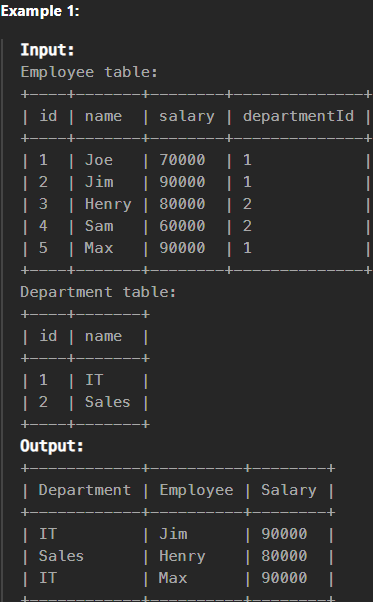

In [10]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

# 1. Define schemas
emp_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("name", StringType(), True),
    StructField("salary", IntegerType(), True),
    StructField("departmentId", IntegerType(), True)
])

dept_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("name", StringType(), True)
])

# 2. Load the data
emp_data = [
    (1, 'Joe', 70000, 1),
    (2, 'Jim', 90000, 1),
    (3, 'Henry', 80000, 2),
    (4, 'Sam', 60000, 2),
    (5, 'Max', 90000, 1)
]

dept_data = [
    (1, 'IT'),
    (2, 'Sales')
]

employee_df = spark.createDataFrame(emp_data, schema=emp_schema)
department_df = spark.createDataFrame(dept_data, schema=dept_schema)

windowSpec=Window.partitionBy('departmentId').orderBy(F.col("salary").desc())

rnk_df=employee_df.withColumn('rnk', F.dense_rank().over(windowSpec))

high_df=rnk_df.filter("rnk==1").drop(F.col("rnk"))

high_alias=high_df.alias('h')
dept_alias=department_df.alias('d')

(
    high_alias.join(dept_alias, F.col('h.departmentId')==F.col('d.id'), 'inner')
                .select(F.col('d.name').alias('Department'),
                        F.col('h.name').alias('employee'),
                        F.col('h.salary'))
                .show()
)

+----------+--------+------+
|Department|employee|salary|
+----------+--------+------+
|        IT|     Max| 90000|
|        IT|     Jim| 90000|
|     Sales|   Henry| 80000|
+----------+--------+------+





---



**10.** **A company's executives are interested in seeing who earns the most money in each of the company's departments. A high earner in a department is an employee who has a salary in the top three unique salaries for that department.**

**Write a solution to find the employees who are high earners in each of the departments.**



```
WITH cte_highest_sal AS(
    SELECT
        e.name AS Employee,
        e.salary,
        d.name,
        DENSE_RANK() OVER(PARTITION BY d.name ORDER BY e.salary desc, d.name ASC) AS sal_rank
    FROM employee e
    INNER JOIN department d
        ON e.departmentId=d.id
)

SELECT
    name AS "Department",
    Employee,
    salary
FROM cte_highest_sal
WHERE sal_rank<=3;
```

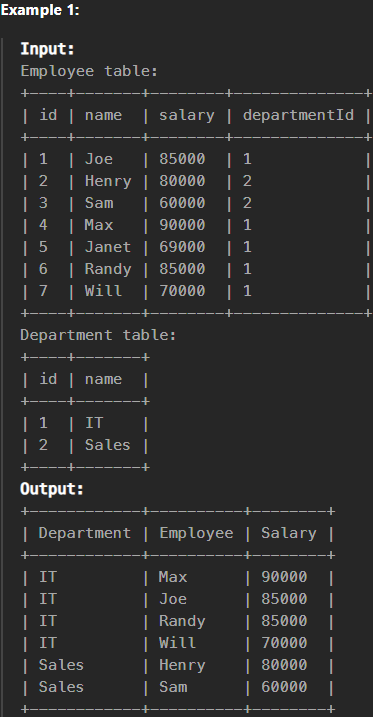

In [11]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

emp_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("name", StringType(), True),
    StructField("salary", IntegerType(), True),
    StructField("departmentId", IntegerType(), True)
])

emp_data = [
    (1, 'Joe', 85000, 1),
    (2, 'Henry', 80000, 2),
    (3, 'Sam', 60000, 2),
    (4, 'Max', 90000, 1),
    (5, 'Janet', 69000, 1),
    (6, 'Randy', 85000, 1),
    (7, 'Will', 70000, 1)
]


employee_df = spark.createDataFrame(emp_data, schema=emp_schema)


dept_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("name", StringType(), True)
])


dept_data = [
    (1, 'IT'),
    (2, 'Sales')
]

department_df = spark.createDataFrame(dept_data, schema=dept_schema)

from pyspark.sql.window import Window
from pyspark.sql import functions as  F

windowSpec=Window.partitionBy(F.col('departmentId')).orderBy(F.col('salary').desc())
sal_rank_df=employee_df.withColumn('rnk',F.dense_rank().over(windowSpec)).filter("rnk<=3").drop("rnk")


dept_alias=department_df.alias('d')
emp_alias=sal_rank_df.alias('e')

(
emp_alias.join(dept_alias,F.col('e.departmentId')==F.col('d.id'), "inner")
              .select(
                  F.col('d.name').alias('Department'),
                  F.col('e.name').alias('salary'),
                  F.col('e.salary')
              ).show()
)

+----------+------+------+
|Department|salary|salary|
+----------+------+------+
|        IT|  Will| 70000|
|        IT| Randy| 85000|
|        IT|   Joe| 85000|
|        IT|   Max| 90000|
|     Sales|   Sam| 60000|
|     Sales| Henry| 80000|
+----------+------+------+





---



**11. Write a solution to find all dates' id with higher temperatures compared to its previous dates (yesterday).**

```
WITH cte_rnum AS
(
    SELECT
        id,
        recordDate,
        temperature,
        LAG(temperature,1) OVER(ORDER BY recorddate) AS prev_day_temp,
        LAG(recorddate,1) OVER(ORDER BY recorddate) AS prev_date
    FROM
        weather
)
SELECT
    id
FROM cte_rnum
WHERE recorddate=adddate(prev_date, 1) AND  temperature>prev_day_temp;
```
```
WITH cte_rnum AS
(
    SELECT
        id,
        recordDate,
        temperature,
        LAG(temperature,1) OVER(ORDER BY recorddate) AS prev_day_temp,
        LAG(recorddate,1) OVER(ORDER BY recorddate) AS prev_date
    FROM
        weather
)
SELECT
    id
FROM cte_rnum
WHERE datediff(recorddate,prev_date)= 1 AND  temperature>prev_day_temp;
```
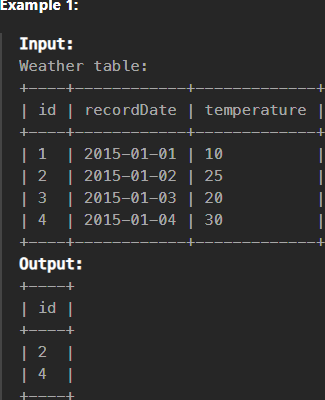



In [18]:
from pyspark.sql.types import StructType, StructField, IntegerType, DateType
from datetime import date

# Define schema for the Weather table
weather_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("recordDate", DateType(), True),
    StructField("temperature", IntegerType(), True)
])

# Prepare data with proper datetime.date objects
weather_data = [
    (1, date(2015, 1, 1), 10),
    (2, date(2015, 1, 2), 25),
    (3, date(2015, 1, 3), 20),
    (4, date(2015, 1, 4), 30)
]

# Create DataFrame
weather_df = spark.createDataFrame(weather_data, schema=weather_schema)

from pyspark.sql.window import Window
from pyspark.sql import functions as F

# Order by recordDate without partitioning by id to allow cross-row lag operations
windowSpec = Window.orderBy(F.col('recordDate'))

trans_weather_df = weather_df.withColumns({
    'prev_temp' : F.lag(F.col('temperature')).over(windowSpec),
    'prev_date' : F.lag(F.col('recordDate')).over(windowSpec)
})


(
    trans_weather_df.filter((F.col('prev_temp') < F.col('temperature')) & (F.date_diff(F.col('recordDate'), F.col('prev_date')) == 1))
                .select("id")
                .show()
)

+---+
| id|
+---+
|  2|
|  4|
+---+

